<a href="https://colab.research.google.com/github/kishoreVP/for_the_love_of_tokens/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
#importing necessary library
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader,TensorDataset
import torchvision.datasets as datasets
import torchvision.transforms as transforms

In [25]:
#Fully Connected Network
class Custom_NN(nn.Module):
  def __init__(self,model_arc,return_layer_list=False):
    super().__init__()
    self.arc = model_arc
    self.layer_map = {
        'relu': nn.ReLU,
        'tanh': nn.Tanh,
        'sigmoid': nn.Sigmoid,
        'softmax': lambda: nn.Softmax(dim=1),
        'dropout': lambda: nn.Dropout(p=0.5),
    }
    self.return_layer_list = return_layer_list
    self.network = self.build()

  def build(self):
      layers = []
      for i in range(1,len(self.arc)):
        current = self.arc[i]
        # Case 1 if string
        if isinstance(current,str):
          if current.lower() in self.layer_map:
            layers.append(self.layer_map[current.lower()]())
          else:
            raise ValueError(f"Add the required function before using it:{current}")
        # Case 2
        elif isinstance(current,int):
          prev = self.arc[i-1]
          if isinstance(prev,str):
            prev = self.arc[i-2]
          layers.append(nn.Linear(prev,current))

      if (self.return_layer_list):
        return layers
      else:
        return nn.Sequential(*layers)

  def forward(self,x): #-> torch.tensor
      x = x.view(x.size(0), -1)
      return self.network(x)

  def train_one_epoch(self,data_loader,loss_function,optimizer):
      self.train() #Set the model to training mode
      total_loss=0
      for inputs,labels in data_loader:
        optimizer.zero_grad()
        outputs = self(inputs)
        loss = loss_function(outputs,labels)
        loss.backward()
        optimizer.step()
        total_loss+=loss.item()
      avg_loss = total_loss/len(data_loader)
      print(f"  Training Loss: {avg_loss:.4f}")


  def test_model(self, data_loader, loss_function):
        self.eval() # Set the model to evaluation mode
        total_loss = 0
        correct_predictions = 0
        total_samples = 0
        with torch.no_grad():
            for inputs, labels in data_loader:
                outputs = self(inputs)
                loss = loss_function(outputs, labels)
                total_loss += loss.item()
                _, predicted_labels = torch.max(outputs, 1)
                total_samples += labels.size(0)
                correct_predictions += (predicted_labels == labels).sum().item()
        avg_loss = total_loss / len(data_loader)
        accuracy = (correct_predictions / total_samples) * 100
        print(f"  Test Loss: {avg_loss:.4f} | Accuracy: {accuracy:.2f}%")


  def train_model(self,train_loader,test_loader,loss_fn,optimizer,epochs):
    for epoch in range(epochs):
      print(f"\n--- Epoch {epoch + 1}/{epochs} ---")
      self.train_one_epoch(train_loader, loss_fn, optimizer)
      self.test_model(test_loader, loss_fn)

### Custom_NN Architecture Input Format

Define your network architecture using a list where:

- **Integers (`int`)** represent the number of neurons in a Linear (fully-connected) layer.
- **Strings (`str`)** represent activation functions or operations like:
  - `"relu"`, `"tanh"`, `"sigmoid"`, `"softmax"`, `"dropout"` (default 0.5), etc.
- **Tuples (`tuple`)** allow configuration of layers like `MaxPool2d`, `Dropout`, etc.

---

#### Supported Layer Types

| Type          | Input Format                    | Description                                |
|---------------|----------------------------------|--------------------------------------------|
| Linear        | `int`                            | Number of neurons in the layer             |
| ReLU          | `"relu"`                         | ReLU activation                            |
| Tanh          | `"tanh"`                         | Tanh activation                            |
| Sigmoid       | `"sigmoid"`                      | Sigmoid activation                         |
| Softmax       | `"softmax"`                      | Softmax (dim=1 by default)                 |
| Dropout       | `"dropout"` or `("dropout", p)`  | Dropout layer with probability `p`         |
| MaxPool2d     | `("maxpool2d", k, s)`            | MaxPool2d with kernel size `k`, stride `s` |

---

#### Example:

```python
cnn_arc = [
    ("conv", 1, 32, 3, 1, 1),  # Conv2d(1, 32, 3, stride=1, padding=1)
    "relu",
    "maxpool_2",               # MaxPool2d(2)
    ("conv", 32, 64, 3, 1, 1),
    "relu",
    "flatten",
    128,
    "relu",
    10,
    "softmax"
]


In [28]:
import torch
import torch.nn as nn

class Custom_CNN(nn.Module):
    def __init__(self, model_arc, input_shape):
        super().__init__()
        self.arc = model_arc
        self.input_shape = input_shape
        self.layer_map = {
            'relu': nn.ReLU,
            'tanh': nn.Tanh,
            'sigmoid': nn.Sigmoid,
            'softmax': lambda: nn.Softmax(dim=1),
            'dropout': lambda: nn.Dropout(p=0.5),
        }
        self.network, self.flattened_size = self.build_cnn()
        self.dense_network = self.build_dense()

    def build_cnn(self):
        layers = []
        x = torch.zeros(1, *self.input_shape)  # Dummy input to trace shape
        for i in range(1, len(self.arc)):
            current = self.arc[i]
            if isinstance(current, tuple):
                layer_type = current[0].lower()
                args = current[1:]
                if layer_type == 'conv':
                    layer = nn.Conv2d(*args)
                elif layer_type == 'maxpool2d':
                    layer = nn.MaxPool2d(*args)
                elif layer_type == 'dropout':
                    layer = nn.Dropout(args[0])
                else:
                    raise ValueError(f"Unknown layer type: {layer_type}")
                layers.append(layer)
                x = layer(x)  # Update shape using dummy input
            elif isinstance(current, str) and current.lower() in self.layer_map:
                act_layer = self.layer_map[current.lower()]()
                layers.append(act_layer)
                x = act_layer(x)
            elif isinstance(current, int):
                break  # Stop at first int (dense part begins)

        flattened_size = x.view(x.size(0), -1).shape[1]
        return nn.Sequential(*layers), flattened_size

    def build_dense(self):
        # Extract dense part of the architecture
        dense_part = [self.flattened_size] + [layer for layer in self.arc if isinstance(layer, int)]
        return Custom_NN(dense_part)

    def forward(self, x):
        x = self.network(x)
        x = x.view(x.size(0), -1)
        x = self.dense_network(x)
        return x

    def train_one_epoch(self, data_loader, loss_function, optimizer):
        self.train()
        total_loss = 0
        for inputs, labels in data_loader:
            optimizer.zero_grad()
            outputs = self(inputs)
            loss = loss_function(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(data_loader)
        print(f"  Training Loss: {avg_loss:.4f}")

    def test_model(self, data_loader, loss_function):
        self.eval()
        total_loss = 0
        correct_predictions = 0
        total_samples = 0
        with torch.no_grad():
            for inputs, labels in data_loader:
                outputs = self(inputs)
                loss = loss_function(outputs, labels)
                total_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total_samples += labels.size(0)
                correct_predictions += (predicted == labels).sum().item()
        avg_loss = total_loss / len(data_loader)
        accuracy = (correct_predictions / total_samples) * 100
        print(f"  Test Loss: {avg_loss:.4f} | Accuracy: {accuracy:.2f}%")

    def train_model(self, train_loader, test_loader, loss_fn, optimizer, epochs):
        for epoch in range(epochs):
            print(f"\n--- Epoch {epoch + 1}/{epochs} ---")
            self.train_one_epoch(train_loader, loss_fn, optimizer)
            self.test_model(test_loader, loss_fn)


--- Epoch 1/2 ---
  Training Loss: 0.2183
  Test Loss: 0.0839 | Accuracy: 97.33%

--- Epoch 2/2 ---
  Training Loss: 0.0638
  Test Loss: 0.0457 | Accuracy: 98.53%


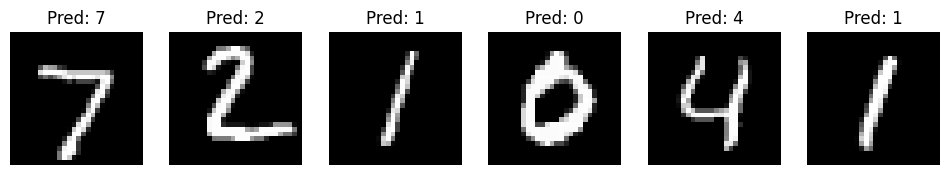

In [29]:
import torch
from torch import nn, optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# 1. DataLoader
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(root='.', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='.', train=False, transform=transform, download=True)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

# 2. Architecture
model_arc = [
    None,
    ('conv', 1, 16, 3), 'relu',
    ('maxpool2d', 2),
    ('conv', 16, 32, 3), 'relu',
    ('maxpool2d', 2),
    128, 'relu',
    10
]

# 3. Model, Loss, Optimizer
model = Custom_CNN(model_arc, input_shape=(1, 28, 28))
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 4. Train the model
model.train_model(train_loader, test_loader, loss_fn, optimizer, epochs=2)

# 5. Visualize predictions
def visualize_predictions(model, data_loader, n=6):
    model.eval()
    images, labels = next(iter(data_loader))
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

    plt.figure(figsize=(12, 4))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(images[i][0], cmap='gray')
        plt.title(f"Pred: {preds[i].item()}")
        plt.axis('off')
    plt.show()

visualize_predictions(model, test_loader)
